## Build A Basic Chatbot With Langgraph(GRAPH API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

graph_builder = StateGraph(State)

In [3]:
graph_builder

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
# os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")


In [6]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=init_chat_model(model="ollama:llama3.1:8b")

d:\ai-engineer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [8]:
graph_builder = StateGraph(State)
graph_builder.add_node("llmchatbot",chatbot)
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph

graph=graph_builder.compile()

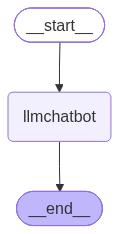

In [9]:
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    pass


In [10]:
response=graph.invoke({"messages":"Hi"})

In [11]:
response['messages'][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [12]:
for event in graph.stream({"messages":"Hi how are you"}):
    for value in event.values():
        print(value['messages'][-1].content)

I'm just a computer program, so I don't have feelings like humans do. But thank you for asking! How can I help or assist you today?


## Chatbot With Tool

In [13]:
from langchain_tavily import TavilySearch

searchTool = TavilySearch(max_results=2)

searchTool.invoke("what is langchain")

{'query': 'what is langchain',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://aws.amazon.com/what-is/langchain',
   'title': 'What is LangChain?',
   'content': 'LangChain is an open source framework for building applications based on large language models (LLMs). LLMs are large deep-learning models pre-trained on large amounts of data that can generate responses to user queries—for example, answering questions or creating images from text-based prompts. LangChain provides tools and abstractions to improve the customization, accuracy, and relevancy of the information the models generate. For example, developers can use LangChain components to build new [...] LangChain provides AI developers with tools to connect language models with external data sources. It is open-source and supported by an active community. Organizations can use LangChain for free and receive support from other developers proficient in the framework.\n\n## How does LangCh

In [14]:
from langchain.tools import tool
@tool
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int
    
        Returns:
            int: output int
    """
    return a*b
tools = [multiply,searchTool]

llm_with_tool=llm.bind_tools(tools=tools)

In [15]:
llm_with_tool

_ChatModelBinding(bound=ChatOllama(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, model='llama3.1:8b'), kwargs={'tools': [{'type': 'function', 'function': {'name': 'multiply', 'description': 'Multiply a and b\n\n    Args:\n        a (int): first int\n        b (int): second int\n\n        Returns:\n            int: output int', 'parameters': {'properties': {'a': {'type': 'integer'}, 'b': {'type': 'integer'}}, 'required': ['a', 'b'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.', 'parameters': {'properties': {'query'

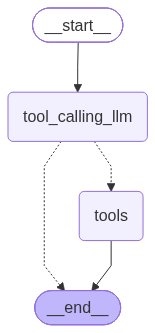

In [16]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
response=graph.invoke({"messages":"What is the recent ai news"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (db0756e5-407f-4480-b3a4-db2ad8afc7db)
 Call ID: db0756e5-407f-4480-b3a4-db2ad8afc7db
  Args:
    query: recent ai news
    time_range: day
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.youtube.com/watch?v=X8K1bW-XfL8", "title": "OpenAI's GPT-6 'Doug', Qwen 4.0 WILL BE INSANE ...", "content": "Subscribe for the latest AI news, model releases, benchmarks, coding agents, open-source AI, and everything happening at the frontier of artificial intelligence! 🔔\n\n[Time Stamps]:\n0:00 - Intro\n1:26 - GPT-6 'Doug'\n5:07 - Qwen 4.0\n5:54 - How To Use\n7:03 - Kiana Demo\n8:59 - Beats Fable 5\n10:05 - Three.js

In [18]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  multiply (de43168f-bc8f-44d4-814e-285bd27f23ce)
 Call ID: de43168f-bc8f-44d4-814e-285bd27f23ce
  Args:
    a: 5
    b: 10
  tavily_search (9e26394d-d1db-428d-bd43-e0c7a561103b)
 Call ID: 9e26394d-d1db-428d-bd43-e0c7a561103b
  Args:
    query: recent AI news
    search_depth: advanced
================================= Tool Message =================================
Name: multiply

50
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/innovation-and-ai/technology/ai/google-ai-updates-july-2026", "title": "The latest AI news we announced in July 2026", "content": "July brought a wave of A

# ReAct Agent Architecture

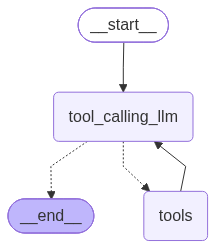

In [19]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (666c709e-9ca5-4b33-80e8-edc4f1067866)
 Call ID: 666c709e-9ca5-4b33-80e8-edc4f1067866
  Args:
    query: recent AI news
    start_date: 2024-01-01
    search_depth: advanced
  multiply (f9d794c9-cc69-4af8-a6b5-e3a784fd5aae)
 Call ID: f9d794c9-cc69-4af8-a6b5-e3a784fd5aae
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.artificialintelligence-news.com", "title": "AI News | Latest News | Insights Powering AI-Driven Business Growth", "content": "AI in Action\n\nJuly 21, 2026\n\n### AWS GraphRAG deployment cuts drug research cycles by 87%\n\nHealthcare & 

# Adding Memory In Agentic Graph

In [21]:
response=graph.invoke({"messages":"Hello my name is Yogesh Bhandari"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Yogesh Bhandari
================================== Ai Message ==================================
Tool Calls:
  tavily_search (3121dd8c-f080-44bc-8a11-aec0a6da0b15)
 Call ID: 3121dd8c-f080-44bc-8a11-aec0a6da0b15
  Args:
    query: Yogesh Bhandari
================================= Tool Message =================================
Name: tavily_search

{"query": "Yogesh Bhandari", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://idrslabs.com/yogesh-bhandari", "title": "Yogesh Bhandari | IDRS Labs", "content": "Yogesh is an expert in finance, business strategy, logistics and supply chain management. He is a dynamic, second generation entrepreneur, adept at spotting unique value propositions and high-potential business opportunities.  \n In the past, he has helped launch and scale up numerous ventures with the right balance of investment and execution. He bri

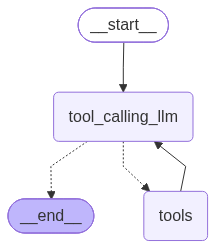

In [22]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
config={"configurable":{"thread_id":"1"}}


In [24]:
response=graph.invoke({"messages":"Hi my name is Yogesh"},config=config)

response

{'messages': [HumanMessage(content='Hi my name is Yogesh', additional_kwargs={}, response_metadata={}, id='d906a40a-8155-4104-9105-63dddb0f7bde'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2026-08-11T04:41:27.8690443Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2508937600, 'load_duration': 722979000, 'prompt_eval_count': 1473, 'prompt_eval_duration': 169258000, 'eval_count': 21, 'eval_duration': 1506855000, 'logprobs': None, 'model_name': 'llama3.1:8b', 'model_provider': 'ollama'}, id='lc_run--019fef20-166e-73d2-8cdb-beec548b4150-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'Yogesh'}, 'id': '0161a608-b3a1-4c07-afc7-b1294a19f3a9', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1473, 'output_tokens': 21, 'total_tokens': 1494}),
  ToolMessage(content='{"query": "Yogesh", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://en.wikipedia

In [25]:
response=graph.invoke({"messages":"what is my name"},config=config)

response

{'messages': [HumanMessage(content='Hi my name is Yogesh', additional_kwargs={}, response_metadata={}, id='d906a40a-8155-4104-9105-63dddb0f7bde'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2026-08-11T04:41:27.8690443Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2508937600, 'load_duration': 722979000, 'prompt_eval_count': 1473, 'prompt_eval_duration': 169258000, 'eval_count': 21, 'eval_duration': 1506855000, 'logprobs': None, 'model_name': 'llama3.1:8b', 'model_provider': 'ollama'}, id='lc_run--019fef20-166e-73d2-8cdb-beec548b4150-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'Yogesh'}, 'id': '0161a608-b3a1-4c07-afc7-b1294a19f3a9', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1473, 'output_tokens': 21, 'total_tokens': 1494}),
  ToolMessage(content='{"query": "Yogesh", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://en.wikipedia

In [26]:
response=graph.invoke({"messages":"do you remember me?"},config=config)

response

{'messages': [HumanMessage(content='Hi my name is Yogesh', additional_kwargs={}, response_metadata={}, id='d906a40a-8155-4104-9105-63dddb0f7bde'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2026-08-11T04:41:27.8690443Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2508937600, 'load_duration': 722979000, 'prompt_eval_count': 1473, 'prompt_eval_duration': 169258000, 'eval_count': 21, 'eval_duration': 1506855000, 'logprobs': None, 'model_name': 'llama3.1:8b', 'model_provider': 'ollama'}, id='lc_run--019fef20-166e-73d2-8cdb-beec548b4150-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'Yogesh'}, 'id': '0161a608-b3a1-4c07-afc7-b1294a19f3a9', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1473, 'output_tokens': 21, 'total_tokens': 1494}),
  ToolMessage(content='{"query": "Yogesh", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://en.wikipedia

# Streaming

In [27]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [28]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

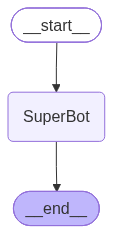

In [29]:

graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [30]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='66df249e-67e4-435a-b61d-4b9144f2f7c1'),
  AIMessage(content="Nice to meet you, Krish! Cricket's a fantastic sport, isn't it? What's your favorite team or player in the world of cricket? Are you more into Test cricket, One-Day Internationals (ODIs), or Twenty20 (T20) cricket? Let's chat about all things cricket!", additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2026-08-11T04:42:11.6529504Z', 'done': True, 'done_reason': 'stop', 'total_duration': 5425400200, 'load_duration': 699318400, 'prompt_eval_count': 20, 'prompt_eval_duration': 207949000, 'eval_count': 64, 'eval_duration': 4333783000, 'logprobs': None, 'model_name': 'llama3.1:8b', 'model_provider': 'ollama'}, id='lc_run--019fef20-b612-7490-a468-b7ae82020e1b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 20, 'output_tokens': 64, 'total_tokens': 84})]}

# Streaming
## Methods: .stream() and astream()

These methods are sync and async methods for streaming back results.
Additional parameters in streaming modes for graph state

values : This streams the full state of the graph after each node is called.

updates : This streams updates to the state of the graph after each node is called.

In [31]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Yogesh Bhandari And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Nice to meet you, Yogesh! Cricket is a fantastic sport, isn't it? Which team or player are you most fond of? Are you a fan of the Indian national cricket team (since you share a common last name with some notable cricketers!) or do you have a favorite league like the IPL? Let's chat about cricket!", additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2026-08-11T05:08:08.0557069Z', 'done': True, 'done_reason': 'stop', 'total_duration': 15988441100, 'load_duration': 10924837500, 'prompt_eval_count': 24, 'prompt_eval_duration': 382000000, 'eval_count': 71, 'eval_duration': 4655546000, 'logprobs': None, 'model_name': 'llama3.1:8b', 'model_provider': 'ollama'}, id='lc_run--019fef38-4c78-7951-9734-c5f7cdeb4f7e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 24, 'output_tokens': 71, 'total_tokens': 95})]}}


In [32]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Yogesh Bhandari And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Yogesh Bhandari And I like cricket', additional_kwargs={}, response_metadata={}, id='0b0e2223-3f74-433b-b7cb-4ad387469d9d'), AIMessage(content="Nice to meet you, Yogesh! Cricket is a fantastic sport, isn't it? Which team or player are you most fond of? Are you a fan of the Indian national cricket team (since you share a common last name with some notable cricketers!) or do you have a favorite league like the IPL? Let's chat about cricket!", additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2026-08-11T05:08:08.0557069Z', 'done': True, 'done_reason': 'stop', 'total_duration': 15988441100, 'load_duration': 10924837500, 'prompt_eval_count': 24, 'prompt_eval_duration': 382000000, 'eval_count': 71, 'eval_duration': 4655546000, 'logprobs': None, 'model_name': 'llama3.1:8b', 'model_provider': 'ollama'}, id='lc_run--019fef38-4c78-7951-9734-c5f7cdeb4f7e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input

In [34]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Yogesh Bhandari And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Nice to meet you too, Yogesh! Another cricket enthusiast!\n\nSo, are you from India, and if so, which team do you support in the Indian Premier League (IPL)? Or perhaps you're a fan of Test cricket and follow teams like Mumbai or Delhi?\n\nLet's chat about cricket!", additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2026-08-11T05:09:37.7908421Z', 'done': True, 'done_reason': 'stop', 'total_duration': 5309863600, 'load_duration': 668035400, 'prompt_eval_count': 99, 'prompt_eval_duration': 371922000, 'eval_count': 62, 'eval_duration': 4260346999, 'logprobs': None, 'model_name': 'llama3.1:8b', 'model_provider': 'ollama'}, id='lc_run--019fef39-d4bf-74d2-9a66-23c575ad5a82-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 99, 'output_tokens': 62, 'total_tokens': 161})]}}


In [35]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='cc26f8f1-23b1-40ea-a258-ca5995845bc6'), AIMessage(content="Nice to meet you, Krish! Cricket is a fantastic sport, isn't it? Which team or player do you support the most in international cricket?\n\nAre you into domestic cricket as well, or more of a fan of Test matches, ODIs, or T20s?", additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2026-08-11T05:09:27.2548937Z', 'done': True, 'done_reason': 'stop', 'total_duration': 4573116700, 'load_duration': 651233400, 'prompt_eval_count': 20, 'prompt_eval_duration': 384977000, 'eval_count': 56, 'eval_duration': 3506257000, 'logprobs': None, 'model_name': 'llama3.1:8b', 'model_provider': 'ollama'}, id='lc_run--019fef39-ae76-75e2-8bc9-854a7daad80f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 20, 'output_tokens': 56, 'total_tokens': 76}), HumanMessage(content='Hi,My 

In [36]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Yogesh Bhandari and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Yogesh Bhandari and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019fef3a-bbe0-7400-9cbd-314f748cd7e1', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Yogesh Bhandari and I like to play cricket', additional_kwargs={}, response_metadata={}, id='c42d64ab-27c4-44e6-b25d-cd3bfa099f7f')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019fef3a-bbfb-7aa2-8377-1fc5a878260d', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:25f2d12a-3608-0272-118f-3d08104b2bd6'}, 'parent_ids': ['019fef3a-bbe0-7400-9cbd-314f748cd7e1']}
{'event': 'on_chat_model_start', 'data': {'